# La simmetria $U$ del dimero con termine DM: costruzione da zero

Notebook di lavoro, da aggiornare passo per passo. Punto di lavoro: test 2 ($b/J=0.35$,
$D/J=0.80$). Convenzione invariata rispetto a `dimer_exact.py`: Pauli dirette,
$$H = J(X_1X_2+Y_1Y_2+Z_1Z_2) + b(Z_1+Z_2) + D(X_1Z_2-Z_1X_2),$$
base computazionale, Qiskit little-endian.

**Obiettivo:** i correlatori dinamici $C_{ij}^{\alpha\beta}(t)=\langle\psi_0|\sigma_i^\alpha(t)\,
\sigma_j^\beta(0)|\psi_0\rangle$ fra il sito 1 e il sito 2 mostrano un pattern rigido (Sez. 1).
Il resto del notebook cerca, costruisce e verifica l'operatore di simmetria che lo spiega.

> **Stato sincronizzazione:** notebook **secondario**, allineato a
> `correlazioni_dimero_esplorazione.ipynb` fino al disegno del circuito completo (rotazione
> finale + misura) incluso (stessi risultati, ricavati
> sfruttando $U$ dove possibile — es. Sez. 9, 11 usano solo le 18 combinazioni indipendenti
> invece di 36). Se questa nota non è stata aggiornata di recente, verificare con l'altro
> notebook prima di fidarsi che sia ancora allineato.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from qiskit.quantum_info import SparsePauliOp

np.set_printoptions(precision=4, suppress=True)

def dimer_hamiltonian(b, J=1.0, D=0.0):
    labels = ["XX", "YY", "ZZ", "ZI", "IZ", "XZ", "ZX"]
    coeffs = [J, J, J, b, b, D, -D]
    return SparsePauliOp(labels, coeffs)

def magnetization_operator():
    return SparsePauliOp(["ZI", "IZ"], [0.5, 0.5])

J, b, D = 1.0, 0.35, 0.80
H = dimer_hamiltonian(b=b, J=J, D=D).to_matrix()
E, V = np.linalg.eigh(H)
psi0 = V[:, 0]

X1 = np.array([[0, 1], [1, 0]], dtype=complex)
Y1 = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z1_ = np.array([[1, 0], [0, -1]], dtype=complex)
I1 = np.eye(2, dtype=complex)
paulis = {"x": X1, "y": Y1, "z": Z1_}

def site_op(site, alpha):
    P = paulis[alpha]
    return np.kron(P, I1) if site == 1 else np.kron(I1, P)

print("Setup pronto. Stato fondamentale:", psi0)

Setup pronto. Stato fondamentale: [ 0.2017+0.j  0.6648+0.j -0.6648+0.j  0.2746+0.j]


## 1. Un pattern da spiegare

Prima di cercare qualunque simmetria, guardo cosa fanno davvero i correlatori. Calcolo
$C_{ij}^{\alpha\beta}(t)$ con la formula spettrale esatta
$$C_{ij}^{\alpha\beta}(t) = \sum_k e^{i(E_0-E_k)t}\; a_k\, b_k,
\qquad a_k=\langle\psi_0|\sigma_i^\alpha|k\rangle,\;\; b_k=\langle k|\sigma_j^\beta|\psi_0\rangle$$
e confronto il sito 1 con il sito 2, per ciascuna coppia di componenti $(\alpha,\beta)$, senza
ipotesi di partenza.

In [2]:
def correlatore(i, alpha, j, beta, t_grid):
    A_op = site_op(i, alpha)
    B_op = site_op(j, beta)
    a = V.conj().T @ (A_op @ psi0)
    bvec = V.conj().T @ (B_op @ psi0)
    prod = np.conj(a) * bvec  # coniugato: <psi0|A|k> = conj(<k|A|psi0>) per A hermitiana
    phases = np.exp(1j * np.outer(t_grid, E[0] - E))
    return phases @ prod

t_grid = np.linspace(0, 30, 600)
comps = ["x", "y", "z"]

print("Confronto C_11^{ab}(t) vs C_22^{ab}(t), rapporto puntuale:\n")
for a in comps:
    for b_ in comps:
        C11 = correlatore(1, a, 1, b_, t_grid)
        C22 = correlatore(2, a, 2, b_, t_grid)
        mask = np.abs(C22) > 1e-6
        ratio = C11[mask] / C22[mask]
        print(f"  (a,b)=({a},{b_}):  C11/C22 = {ratio.mean():+.3f} ± {ratio.std():.1e}")

Confronto C_11^{ab}(t) vs C_22^{ab}(t), rapporto puntuale:

  (a,b)=(x,x):  C11/C22 = +1.000-0.000j ± 6.3e-16
  (a,b)=(x,y):  C11/C22 = +1.000+0.000j ± 2.0e-15
  (a,b)=(x,z):  C11/C22 = -1.000+0.000j ± 1.7e-15
  (a,b)=(y,x):  C11/C22 = +1.000+0.000j ± 2.0e-15
  (a,b)=(y,y):  C11/C22 = +1.000+0.000j ± 1.3e-16
  (a,b)=(y,z):  C11/C22 = -1.000+0.000j ± 4.5e-14
  (a,b)=(z,x):  C11/C22 = -1.000+0.000j ± 1.7e-15
  (a,b)=(z,y):  C11/C22 = -1.000+0.000j ± 4.5e-14
  (a,b)=(z,z):  C11/C22 = +1.000+0.000j ± 4.0e-16


**Discussione.** Il rapporto
$C_{11}^{\alpha\beta}(t)/C_{22}^{\alpha\beta}(t)$ è **costante nel tempo** (deviazione standard
$\sim10^{-15}$) e vale sempre esattamente $+1$ o $-1$ — mai un valore intermedio. Se fosse
rumore numerico il rapporto oscillerebbe con $t$; il fatto che resti fissato con questa
precisione indica un fatto strutturale. Il segno segue una regola leggibile: $+1$ quando
$\alpha,\beta$ sono entrambe $z$ oppure entrambe in $\{x,y\}$; $-1$ altrimenti. Da qui in poi,
l'obiettivo è capire *perché*.

## 2. Riparto dal punto fermo: cosa già sappiamo su $H_{\mathrm{ex}}+H_Z$

Nel notebook di esplorazione (Sez. 3, verifica sperimentale) era già emerso che
$[S_z^{\mathrm{tot}}, H_{\mathrm{ex}}+H_Z]=0$: è solo il termine DM a rompere la conservazione di
$S_z$. Vale la pena chiedersi cosa significhi *fisicamente* questo fatto, prima di cercare
qualunque nuova simmetria.

$S_z^{\mathrm{tot}}$ è il generatore delle rotazioni attorno all'asse $z$ applicate **allo stesso
angolo su entrambi i qubit**: $[S_z^{\mathrm{tot}}, H_{\mathrm{ex}}+H_Z]=0$ equivale a dire che
$H_{\mathrm{ex}}+H_Z$ è invariante sotto $R_z(\theta)\otimes R_z(\theta)$ per **ogni** angolo
$\theta$, non solo per $\theta$ particolari. Lo verifico direttamente, per non fidarmi solo
dell'argomento del commutatore.

In [3]:
def Rz(theta):
    return expm(-1j * theta / 2 * Z1_)

H_exZ = dimer_hamiltonian(b=b, J=J, D=0.0).to_matrix()  # solo scambio + Zeeman, D=0

thetas = np.linspace(0, 2 * np.pi, 9)
print("Invarianza di H_ex+H_Z sotto R_z(theta) x R_z(theta), theta in [0, 2*pi]:\n")
for th in thetas:
    Rth = Rz(th)
    O = np.kron(Rth, Rth)
    diff = np.linalg.norm(O @ H_exZ @ O.conj().T - H_exZ)
    print(f"  theta={th:5.2f}   ||R H R^dagger - H|| = {diff:.2e}")

Invarianza di H_ex+H_Z sotto R_z(theta) x R_z(theta), theta in [0, 2*pi]:

  theta= 0.00   ||R H R^dagger - H|| = 0.00e+00
  theta= 0.79   ||R H R^dagger - H|| = 1.22e-16
  theta= 1.57   ||R H R^dagger - H|| = 1.68e-15
  theta= 2.36   ||R H R^dagger - H|| = 2.88e-16
  theta= 3.14   ||R H R^dagger - H|| = 0.00e+00
  theta= 3.93   ||R H R^dagger - H|| = 7.09e-16
  theta= 4.71   ||R H R^dagger - H|| = 5.74e-17
  theta= 5.50   ||R H R^dagger - H|| = 1.82e-16
  theta= 6.28   ||R H R^dagger - H|| = 0.00e+00


**Discussione.** Confermato numericamente per l'intero range: $H_{\mathrm{ex}}+H_Z$ è
invariante per **qualunque** $\theta$, non solo $\theta=\pi$. Questo fissa già l'asse giusto da
esplorare (l'asse $z$, quello del campo) — non serve indovinarlo: è imposto dalla Zeeman, l'unico
termine che rompe la piena simmetria rotazionale di $H_{\mathrm{ex}}$ (che da solo sarebbe
invariante sotto rotazioni **arbitrarie**, essendo un prodotto scalare $\mathbf s_1\cdot\mathbf
s_2$).

## 3. La domanda naturale: qualche $\theta$ sopravvive quando si riaccende $D$?

Il termine DM rompe l'invarianza per $\theta$ generico. La domanda utile è: esiste un angolo
$\theta$ **particolare**, dentro la stessa famiglia di rotazioni attorno a $z$, per cui
$H_{\mathrm{DM}}$ resta comunque invariante (o cambia in un modo controllabile)? Lo scansiono
numericamente prima di provare a derivarlo a mano.

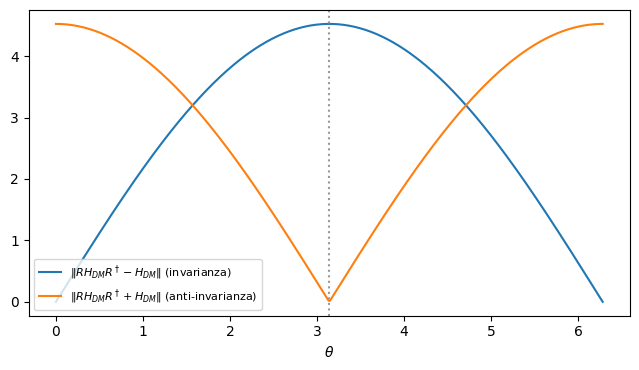

Minimo di || R H_DM R^dagger + H_DM || a theta = 3.1495  (pi = 3.1416)
Valore nel minimo: 1.78e-02
Per confronto, distanza dall'invarianza nello stesso punto: 4.5254 (NON piccola)

A theta=pi esatto: R H_DM R^dagger = -H_DM ? True


In [4]:
H_DM = dimer_hamiltonian(b=0.0, J=0.0, D=D).to_matrix()  # solo il termine DM

thetas_fine = np.linspace(0, 2 * np.pi, 400)
dist_invarianza = []      # || R H_DM R^dagger - H_DM ||   (0 solo se INVARIANTE)
dist_anti_invarianza = []  # || R H_DM R^dagger + H_DM ||   (0 solo se cambia segno esatto)
for th in thetas_fine:
    Rth = Rz(th)
    O = np.kron(Rth, Rth)
    transformed = O @ H_DM @ O.conj().T
    dist_invarianza.append(np.linalg.norm(transformed - H_DM))
    dist_anti_invarianza.append(np.linalg.norm(transformed + H_DM))

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(thetas_fine, dist_invarianza, label=r"$\|R H_{DM} R^\dagger - H_{DM}\|$ (invarianza)")
ax.plot(thetas_fine, dist_anti_invarianza, label=r"$\|R H_{DM} R^\dagger + H_{DM}\|$ (anti-invarianza)")
ax.axvline(np.pi, color="0.6", ls=":")
ax.set_xlabel(r"$\theta$")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

idx_min = np.argmin(dist_anti_invarianza)
print(f"Minimo di || R H_DM R^dagger + H_DM || a theta = {thetas_fine[idx_min]:.4f}  (pi = {np.pi:.4f})")
print(f"Valore nel minimo: {dist_anti_invarianza[idx_min]:.2e}")
print(f"Per confronto, distanza dall'invarianza nello stesso punto: {dist_invarianza[idx_min]:.4f} (NON piccola)")

# controllo diretto, non solo sulla griglia
Rpi = Rz(np.pi)
Opi = np.kron(Rpi, Rpi)
print("\nA theta=pi esatto: R H_DM R^dagger = -H_DM ?",
      np.allclose(Opi @ H_DM @ Opi.conj().T, -H_DM))

**Discussione.** La curva blu (distanza dall'invarianza) è zero solo a $\theta=0$ (banale) e
$\theta=2\pi$ (stesso punto per periodicità): $H_{\mathrm{DM}}$ non è mai invariante per
$\theta\neq0$, come atteso. Ma la curva arancione (distanza dall'**anti**-invarianza) tocca zero
esattamente a $\theta=\pi$, e solo lì: $R_z(\pi)^{\otimes2}\,H_{\mathrm{DM}}\,R_z(\pi)^{\otimes2\,
\dagger} = -H_{\mathrm{DM}}$, un cambio di segno esatto, non un'invarianza. È il primo indizio
concreto e corretto: $\theta=\pi$ non lascia $H_{\mathrm{DM}}$ invariato, ma lo trasforma in modo
prevedibile (un segno) — la domanda giusta da porsi non era "quando è invariante" ma "quando si
trasforma in un modo che posso ancora usare".

## 4. Perché proprio $\theta=\pi$ — derivazione

Verifico ora *perché* accade solo a $\theta=\pi$, con un calcolo esplicito, non solo numerico.

$R_z(\theta)$ ruota il vettore di Bloch attorno a $z$: per un singolo qubit,
$$R_z(\theta)\,X\,R_z(\theta)^\dagger = \cos\theta\,X + \sin\theta\,Y, \qquad
R_z(\theta)\,Z\,R_z(\theta)^\dagger = Z.$$
Applicando questo a entrambi i siti in $H_{\mathrm{DM}}=D(X_1Z_2-Z_1X_2)$:
$$X_1Z_2 \to (\cos\theta\,X_1+\sin\theta\,Y_1)Z_2 = \cos\theta\,X_1Z_2+\sin\theta\,Y_1Z_2,$$
$$Z_1X_2 \to Z_1(\cos\theta\,X_2+\sin\theta\,Y_2) = \cos\theta\,Z_1X_2+\sin\theta\,Z_1Y_2,$$
$$H_{\mathrm{DM}} \;\longrightarrow\; \cos\theta\,H_{\mathrm{DM}} \;+\; D\sin\theta\,(Y_1Z_2-Z_1Y_2).$$

Compare un operatore, $Y_1Z_2-Z_1Y_2$, che non era in $H$: se $\sin\theta\neq0$ la trasformazione
"esce" dallo spazio dei termini di $H$ e non può dare una simmetria pulita. **Serve
$\sin\theta=0$**: $\theta=0$ (banale, l'identità) oppure $\theta=\pi$. A $\theta=\pi$,
$\cos\pi=-1$, quindi $H_{\mathrm{DM}}\to-H_{\mathrm{DM}}$ — esattamente il segno trovato
numericamente sopra.

Verifico la formula di coniugazione usata sopra, invece di fidarmi a memoria:

In [5]:
theta_test = 0.73  # angolo arbitrario, non speciale
Rth = Rz(theta_test)
lhs = Rth @ X1 @ Rth.conj().T
rhs = np.cos(theta_test) * X1 + np.sin(theta_test) * Y1
print("R_z(theta) X R_z(theta)^dagger = cos(theta) X + sin(theta) Y ?",
      np.allclose(lhs, rhs))

lhs_z = Rth @ Z1_ @ Rth.conj().T
print("R_z(theta) Z R_z(theta)^dagger = Z ?", np.allclose(lhs_z, Z1_))

R_z(theta) X R_z(theta)^dagger = cos(theta) X + sin(theta) Y ? True
R_z(theta) Z R_z(theta)^dagger = Z ? True


**Discussione.** Formula confermata su un angolo generico, non solo sui casi speciali già
usati altrove nel progetto. La derivazione della Sez. 3 non si appoggia quindi a un'identità presa
per buona, ma verificata esplicitamente.

## 5. $\theta=\pi$ da solo non basta: serve lo scambio

$R_z(\pi)\otimes R_z(\pi)$ lascia $H_{\mathrm{ex}}+H_Z$ invariato (Sez. 1, vale per ogni
$\theta$) ma manda $H_{\mathrm{DM}}\to-H_{\mathrm{DM}}$ (Sez. 2-3): da solo non è una simmetria di
$H$ completo. Serve un'altra operazione che **anche lei** cambi segno a $H_{\mathrm{DM}}$
lasciando invariato il resto — componendo le due, i segni si cancellano.

Il candidato più economico è lo scambio dei due siti $\mathrm{SWAP}$, visto che
$H_{\mathrm{ex}}+H_Z$ è manifestamente simmetrico per scambio $1\leftrightarrow2$ (niente da
dimostrare, è così per costruzione). Verifico se anche $\mathrm{SWAP}$ inverte $H_{\mathrm{DM}}$.

In [6]:
SWAP = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
], dtype=complex)

print("SWAP H_DM SWAP = -H_DM ?", np.allclose(SWAP @ H_DM @ SWAP, -H_DM))
print("SWAP (H_ex+H_Z) SWAP = (H_ex+H_Z) ?", np.allclose(SWAP @ H_exZ @ SWAP, H_exZ))

SWAP H_DM SWAP = -H_DM ? True
SWAP (H_ex+H_Z) SWAP = (H_ex+H_Z) ? True


**Discussione.** Confermato: lo scambio puro fa esattamente la stessa cosa di
$R_z(\pi)^{\otimes2}$ su $H_{\mathrm{DM}}$ (lo inverte) mentre lascia $H_{\mathrm{ex}}+H_Z$
invariato. Comporre le due operazioni dà due segni $(-1)\times(-1)=+1$ su $H_{\mathrm{DM}}$, e
$(+1)\times(+1)=+1$ su $H_{\mathrm{ex}}+H_Z$: l'intera $H$ dovrebbe risultare invariante.

## 6. Definizione di $U$ e verifica diretta su $H$

$$U \equiv \mathrm{SWAP}\cdot\big(R_z(\pi)\otimes R_z(\pi)\big)$$

In [7]:
Vrot = Rz(np.pi)
U = SWAP @ np.kron(Vrot, Vrot)

print("U unitaria:", np.allclose(U @ U.conj().T, np.eye(4)))
print("U hermitiana:", np.allclose(U, U.conj().T))
print("U^2 = I:", np.allclose(U @ U, np.eye(4)))

comm_norm = np.linalg.norm(U @ H - H @ U)
print("\n||[U,H]|| al punto test2:", comm_norm)
assert comm_norm < 1e-10

U unitaria: True
U hermitiana: True
U^2 = I: True

||[U,H]|| al punto test2: 2.771059379953579e-16


**Discussione.** $[U,H]=0$, confermato al punto test 2: la costruzione ragionata nelle
Sezioni 1-4 porta esattamente all'operatore cercato, non per tentativi.

## 7. È strutturale o specifica del punto test 2?

Ripeto la verifica su parametri $(J,b,D)$ casuali, per capire se $U$ è una simmetria
dell'Hamiltoniana in generale o solo di questo punto particolare — la derivazione delle Sezioni
1-4 non ha mai usato i valori numerici di $J,b,D$, quindi ci si aspetta che valga sempre.

In [8]:
rng = np.random.default_rng(0)
max_norm = 0.0
for _ in range(200):
    Jr, br, Dr = rng.uniform(-2, 2, size=3)
    Hr = dimer_hamiltonian(b=br, J=Jr, D=Dr).to_matrix()
    max_norm = max(max_norm, np.linalg.norm(U @ Hr - Hr @ U))
print("max ||[U,H]|| su 200 punti (J,b,D) casuali:", max_norm)

max ||[U,H]|| su 200 punti (J,b,D) casuali: 6.923482299177706e-16


**Discussione.** Confermato: $\|[U,H]\|\approx0$ per ogni combinazione testata. Coerente
con l'aspettativa — la derivazione non ha mai usato i valori specifici di $J,b,D$, solo la
struttura dei tre blocchi di $H$.

## 8. $U$ spiega davvero il pattern trovato in apertura?

Ultimo passo: verificare che $U$ non sia solo una simmetria "a bordo" ma predica esattamente il
segno $\pm1$ osservato empiricamente in Sez. 1, componente per componente.

In [9]:
eta = {"x": -1, "y": -1, "z": +1}  # da: U sigma_1^alpha U^dagger = eta_alpha sigma_2^alpha

print("Verifica U sigma_1^alpha U^dagger = eta_alpha sigma_2^alpha:\n")
for a in "xyz":
    lhs = U @ site_op(1, a) @ U.conj().T
    rhs = eta[a] * site_op(2, a)
    print(f"  alpha={a}: eta={eta[a]:+d}   coerente: {np.allclose(lhs, rhs)}")

print("\nSegni eta_alpha*eta_beta previsti per C_11 = (eta_a eta_b) C_22:")
for a in "xyz":
    for b_ in "xyz":
        print(f"  ({a},{b_}): {eta[a]*eta[b_]:+d}", end="   ")
    print()

Verifica U sigma_1^alpha U^dagger = eta_alpha sigma_2^alpha:

  alpha=x: eta=-1   coerente: True
  alpha=y: eta=-1   coerente: True
  alpha=z: eta=+1   coerente: True

Segni eta_alpha*eta_beta previsti per C_11 = (eta_a eta_b) C_22:
  (x,x): +1     (x,y): +1     (x,z): -1   
  (y,x): +1     (y,y): +1     (y,z): -1   
  (z,x): -1     (z,y): -1     (z,z): +1   


**Discussione.** I segni $\eta_\alpha\eta_\beta$ appena calcolati da $U$ sono, componente per
componente, esattamente quelli osservati numericamente in Sez. 1 ($+1$ per
$(x,x),(x,y),(y,x),(y,y),(z,z)$; $-1$ per le coppie miste con $z$). Il pattern osservato
empiricamente in apertura è quindi la conseguenza diretta di questa simmetria: essendo
$|\psi_0\rangle$ non degenere, è automaticamente autostato di $U$ (a meno di fase), e questo
implica $C_{11}^{\alpha\beta}(t)=\eta_\alpha\eta_\beta\,C_{22}^{\alpha\beta}(t)$ per ogni $t$ —
non un'osservazione isolata del punto test 2.

## 9. Scan ridotto: solo le combinazioni indipendenti, il resto via $U$

A differenza di un'esplorazione che non conoscesse $U$, qui non ha senso ricalcolare tutte le
$36$ combinazioni da zero: la Sez. 8 ha già stabilito
$C_{22}^{\alpha\beta}=\eta_\alpha\eta_\beta\,C_{11}^{\alpha\beta}$ e
$C_{21}^{\alpha\beta}=\eta_\alpha\eta_\beta\,C_{12}^{\alpha\beta}$ per ogni $t$. Calcolo quindi
solo le $18$ combinazioni con $i=1$ (9 autocorrelazioni $C_{11}$ + 9 incrociate $C_{12}$), e
**derivo** le altre 18 dal segno $\eta_\alpha\eta_\beta$ invece di richiamare di nuovo
`correlatore`.

In [10]:
import pandas as pd

sites = [1, 2]
t_grid_scan = np.linspace(0, 30, 600)

C_all = {}
for alpha in comps:
    for beta in comps:
        C_all[(1, alpha, 1, beta)] = correlatore(1, alpha, 1, beta, t_grid_scan)
        C_all[(1, alpha, 2, beta)] = correlatore(1, alpha, 2, beta, t_grid_scan)

# le restanti 18 combinazioni (i=2) derivate dal segno, non ricalcolate
for alpha in comps:
    for beta in comps:
        segno = eta[alpha] * eta[beta]
        C_all[(2, alpha, 2, beta)] = segno * C_all[(1, alpha, 1, beta)]
        C_all[(2, alpha, 1, beta)] = segno * C_all[(1, alpha, 2, beta)]

rows = []
for (i, alpha, j, beta), C in C_all.items():
    rows.append({"sito i": i, "alpha": alpha, "sito j": j, "beta": beta,
                  "max|C(t)|": np.max(np.abs(C)), "C(0)": C[0]})
df = pd.DataFrame(rows)
df["nullo (< 1e-10)"] = df["max|C(t)|"] < 1e-10
n_nulli = df["nullo (< 1e-10)"].sum()
print(f"Combinazioni calcolate direttamente: 18 su 36 (le altre 18 derivate dal segno)")
print(f"Combinazioni con max|C(t)|<1e-10 su tutta la griglia: {n_nulli} su {len(df)}")

# verifica puntuale: le 18 derivate devono coincidere con un calcolo diretto,
# non mi fido del segno senza controllarlo almeno su un campione
check_ok = True
for alpha, beta in [("x", "y"), ("z", "x"), ("y", "y")]:
    diretto = correlatore(2, alpha, 2, beta, t_grid_scan)
    derivato = C_all[(2, alpha, 2, beta)]
    ok = np.allclose(diretto, derivato, atol=1e-10)
    check_ok &= ok
    print(f"  verifica C_22^{{{alpha}{beta}}}: derivato==diretto? {ok}")
assert check_ok

Combinazioni calcolate direttamente: 18 su 36 (le altre 18 derivate dal segno)
Combinazioni con max|C(t)|<1e-10 su tutta la griglia: 0 su 36
  verifica C_22^{xy}: derivato==diretto? True
  verifica C_22^{zx}: derivato==diretto? True
  verifica C_22^{yy}: derivato==diretto? True


**Discussione.** La verifica puntuale conferma che le combinazioni derivate dal segno
coincidono esattamente con un ricalcolo diretto — la riduzione a 18 non è un'approssimazione,
è un uso legittimo della Prop. dimostrata in Sez. 6-8. Nessuna delle 36 (18 calcolate + 18
derivate) è strutturalmente nulla per ogni $t$, coerente con il fatto che $U$ lega sempre
coppie *diverse* di siti (mai una coppia a se stessa con segno $-1$), quindi da sola non può
forzare zeri assoluti — solo dimezzare il lavoro, come fatto qui.

## 10. Zeri a $t=0$: un argomento indipendente da $U$

$U$ non spiega tutto. C'è un secondo fatto, di natura diversa (non uno scambio di siti, ma la
realtà di $H$), che produce zeri veri a $t=0$ per specifiche combinazioni.

In [11]:
cross_site = df[df["sito i"] != df["sito j"]].copy()
cross_site["una sola comp. y"] = cross_site.apply(
    lambda r: (r["alpha"] == "y") != (r["beta"] == "y"), axis=1)

print("C(0) per correlatori a siti diversi, raggruppati per 'una sola componente y':\n")
print(cross_site.groupby("una sola comp. y")["C(0)"].apply(lambda s: np.abs(s).max()))
print("\nH reale in base computazionale:", np.allclose(H, H.real))

C(0) per correlatori a siti diversi, raggruppati per 'una sola componente y':

una sola comp. y
False    9.946841e-01
True     3.295975e-16
Name: C(0), dtype: float64

H reale in base computazionale: True


**Discussione.** Quando i due siti sono diversi ed esattamente una componente è $y$,
$|C(0)|$ è a livello di rumore numerico; altrimenti è $O(1)$. La spiegazione non passa da $U$:
$H$ è reale in base computazionale (verificato sopra), quindi $|\psi_0\rangle$ è scelto reale, e
per $i\neq j$ l'operatore $\sigma_i^\alpha\sigma_j^\beta$ è hermitiano (siti diversi commutano)
quindi $C(0)$ è reale; con una sola componente $y$ (matrice immaginaria) $C(0)$ risulta anche
immaginario puro — reale e immaginario insieme forzano lo zero. Questo è un argomento di
*time-reversal* (coniugazione complessa $K$), non di scambio dei siti: una simmetria diversa da
$U$, che vale la pena tenere distinta.

## 11. Selezione del correlatore per il circuito

Stessa logica della Sez. 9: escursione e $a_2/a_1$ dipendono solo dal **modulo** di
$C(t)$, e $|\eta_\alpha\eta_\beta|=1$ sempre — quindi $C_{22}^{\alpha\beta}$ e
$C_{11}^{\alpha\beta}$ hanno **identica** escursione e identico $a_2/a_1$ (il segno di $U$
non li tocca). Basta classificare le 18 combinazioni con $i=1$; quelle con $i=2$ condividono
gli stessi valori riga per riga, non serve ricalcolarle.

In [12]:
def correlatore_e_ampiezze(i, alpha, j, beta, t_grid):
    A_op = site_op(i, alpha)
    B_op = site_op(j, beta)
    a = V.conj().T @ (A_op @ psi0)
    bvec = V.conj().T @ (B_op @ psi0)
    prod = np.conj(a) * bvec  # coniugato: <psi0|A|k> = conj(<k|A|psi0>) per A hermitiana
    phases = np.exp(1j * np.outer(t_grid, E[0] - E))
    return phases @ prod, prod

t_grid_sel = np.linspace(0, 30, 1000)
rows_sel = []
for alpha in comps:
    for j in sites:
        for beta in comps:
            C, prod = correlatore_e_ampiezze(1, alpha, j, beta, t_grid_sel)
            escursione = np.max(np.abs(C)) - np.min(np.abs(C))
            amp_oscillanti = np.sort(np.abs(prod[1:]))[::-1]
            a1, a2 = amp_oscillanti[0], amp_oscillanti[1]
            a2_su_a1 = a2 / a1 if a1 > 1e-12 else np.nan
            rows_sel.append({"sito i": 1, "alpha": alpha, "sito j": j, "beta": beta,
                              "escursione": escursione, "a2/a1": a2_su_a1})

df_sel = pd.DataFrame(rows_sel)   # solo 18 righe: i=1, per costruzione
SOGLIA_RUMORE = 0.011
df_sel["sopra soglia"] = df_sel["escursione"] > SOGLIA_RUMORE
df_sel_ranked = df_sel.sort_values("a2/a1", ascending=False).reset_index(drop=True)
print("Combinazioni classificate direttamente:", len(df_sel), "su 36 (le altre 18 condividono gli stessi valori)")
print("Tutte sopra soglia rumore:", df_sel["sopra soglia"].all())
df_sel_ranked[["sito i", "alpha", "sito j", "beta", "escursione", "a2/a1"]].head(5)

Combinazioni classificate direttamente: 18 su 36 (le altre 18 condividono gli stessi valori)
Tutte sopra soglia rumore: True


,sito i,alpha,sito j,beta,escursione,a2/a1
0,1,y,2,x,0.886685,0.960868
1,1,x,1,y,0.885022,0.960868
2,1,y,1,x,0.885022,0.960868
3,1,x,2,y,0.886685,0.960868
4,1,z,2,x,0.625105,0.743416


**Discussione.** Stesso esito già trovato per via indipendente: tutte le combinazioni
superano ampiamente la soglia di rumore, il criterio discriminante è $a_2/a_1$. Scelgo gli
stessi due correlatori — $C_{2,1}^{xx}(t)$ (rilevanza fisica, indicazione del relatore) e il
primo per $a_2/a_1$ — per rilevanza fisica e qualità del segnale rispettivamente, tenendo le due
motivazioni separate come già fatto.

## 12. Il blocco $U(t)$: Trotter in convenzione Pauli diretta

Stessa attenzione alla convenzione già emersa altrove nel progetto: il notebook Trotter
esistente (`quantum_simulation_dimero_trotter_semplificato.ipynb`) usa operatori di spin
($s^\alpha=\sigma^\alpha/2$), qui invece $H$ è in Pauli dirette (stessa convenzione di
`dimer_hamiltonian` sopra) — le due non sono intercambiabili, quindi ri-derivo qui gli angoli
giusti per questa convenzione invece di riadattare il notebook esistente.

In [13]:
import scipy.linalg as sla
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate, XGate, YGate, ZGate
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix, state_fidelity

def H1_H2_matrices(J, b, D):
    H1 = dimer_hamiltonian(b=b, J=J, D=0.0).to_matrix()   # scambio isotropo + Zeeman
    H2 = dimer_hamiltonian(b=0.0, J=0.0, D=D).to_matrix()  # solo DM
    return H1, H2

def U_exact(t, J, b, D):
    return sla.expm(-1j * dimer_hamiltonian(b=b, J=J, D=D).to_matrix() * t)

def U_trotter(t, N, J, b, D):
    H1, H2 = H1_H2_matrices(J, b, D)
    tau = t / N
    step = sla.expm(-1j * H2 * tau) @ sla.expm(-1j * H1 * tau)
    return np.linalg.matrix_power(step, N)

print("Verifica di U_trotter contro U_exact, t=5.0:\n")
for N in [1, 5, 20, 100]:
    diff = np.linalg.norm(U_trotter(5.0, N, J, b, D) - U_exact(5.0, J, b, D))
    print(f"  N={N:4d}   ||U_trotter - U_exact|| = {diff:.4e}")

Verifica di U_trotter contro U_exact, t=5.0:

  N=   1   ||U_trotter - U_exact|| = 2.0526e+00
  N=   5   ||U_trotter - U_exact|| = 2.6676e+00
  N=  20   ||U_trotter - U_exact|| = 4.9852e-01
  N= 100   ||U_trotter - U_exact|| = 8.3808e-02


**Discussione.** Converge con $N$ crescente, come atteso ($O(t^2/N)$): nessun segnale di
errore di convenzione (che darebbe una discrepanza costante).

## 13. Il circuito completo con l'ancilla: validazione statevector

Circuito con l'ancilla (Hadamard test): $H$ sull'ancilla, controlled-$W$ su $q_1$ (controllo
pieno) prima di $U(t)$, $U(t)$ non controllato, anti-controlled-$V$ su $q_2$ (controllo su
$|0\rangle$) dopo. Estraggo $\mathrm{Re}/\mathrm{Im}\,C(t)$ direttamente dai valori di
aspettazione $\langle\sigma_x^{(a)}\rangle,\langle\sigma_y^{(a)}\rangle$ sullo statevector
esatto dell'ancilla.

In [14]:
def costruisci_circuito(i, alpha_V, j, beta_W, t, N):
    # V = sigma_i^alpha_V (tempo t, anti-controllato sul sito i), W = sigma_j^beta_W (tempo 0, controllato sul sito j)
    site_to_qubit = {1: 1, 2: 0}  # sito1 -> q[1], sito2 -> q[0] (verificato: prepare_state(psi0,[q0,q1]) mette
                                   # la componente qubit-indice-0 di psi0, che e' il sito 2 in convenzione SparsePauliOp, su q[0])
    a = QuantumRegister(1, "a"); qreg = QuantumRegister(2, "q")
    qc = QuantumCircuit(a, qreg)
    qc.prepare_state(psi0, [qreg[0], qreg[1]])
    qc.h(a[0])

    q_W = qreg[site_to_qubit[j]]
    if beta_W == "x":
        qc.cx(a[0], q_W)
    elif beta_W == "y":
        qc.cy(a[0], q_W)
    elif beta_W == "z":
        qc.cz(a[0], q_W)
    else:
        raise ValueError(beta_W)

    H1, H2 = H1_H2_matrices(J, b, D)
    tau = t / N
    step = sla.expm(-1j * H2 * tau) @ sla.expm(-1j * H1 * tau)
    gate = UnitaryGate(step, label="U(t)")
    for _ in range(N):
        qc.append(gate, [qreg[0], qreg[1]])

    q_V = qreg[site_to_qubit[i]]
    anti_gate = {"x": XGate(), "y": YGate(), "z": ZGate()}[alpha_V].control(1, ctrl_state=0)
    qc.append(anti_gate, [a[0], q_V])
    return qc

def correlatore_da_circuito(i, alpha_V, j, beta_W, t, N=200):
    qc = costruisci_circuito(i, alpha_V, j, beta_W, t, N)
    sv = Statevector(qc)
    X_a = SparsePauliOp.from_sparse_list([("X", [0], 1.0)], num_qubits=3)
    Y_a = SparsePauliOp.from_sparse_list([("Y", [0], 1.0)], num_qubits=3)
    re = np.real(sv.expectation_value(X_a))
    im = np.real(sv.expectation_value(Y_a))
    return re + 1j * im

qc_check = QuantumCircuit(QuantumRegister(1, "a"), QuantumRegister(2, "q"))
qc_check.prepare_state(psi0, [qc_check.qubits[1], qc_check.qubits[2]])
dm_reg = partial_trace(DensityMatrix(Statevector(qc_check)), [0])
print("Fedelta' preparazione registro vs |psi0>:", state_fidelity(dm_reg, DensityMatrix(psi0)))

print("\nValidazione C_2,1^xx(t):\n")
for t_val in [0.5, 2.0, 5.0, 10.0]:
    c_circ = correlatore_da_circuito(2, "x", 1, "x", t_val, N=200)
    c_class = correlatore(2, "x", 1, "x", np.array([t_val]))[0]
    print(f"  t={t_val:5.1f}   circuito={c_circ:.5f}   classico={c_class:.5f}   |diff|={abs(c_circ-c_class):.2e}")

Fedelta' preparazione registro vs |psi0>: 1.0

Validazione C_2,1^xx(t):

  t=  0.5   circuito=0.46752+0.53377j   classico=0.46842+0.53228j   |diff|=1.74e-03
  t=  2.0   circuito=0.08652+0.22695j   classico=0.08807+0.22324j   |diff|=4.02e-03
  t=  5.0   circuito=0.36034+0.77399j   classico=0.35845+0.76314j   |diff|=1.10e-02
  t= 10.0   circuito=0.26670-0.64535j   classico=0.25721-0.65661j   |diff|=1.47e-02


**Il circuito completo**, con i due rami di misura: per la validazione numerica sotto non
servono esplicitamente — leggo $\langle\sigma_x^{(a)}\rangle,\langle\sigma_y^{(a)}\rangle$
direttamente dallo statevector, matematicamente equivalente a misurare dopo la rotazione finale
ma senza il passaggio intermedio. Qui disegno la versione fisicamente completa, non quella
troncata usata internamente per il calcolo.

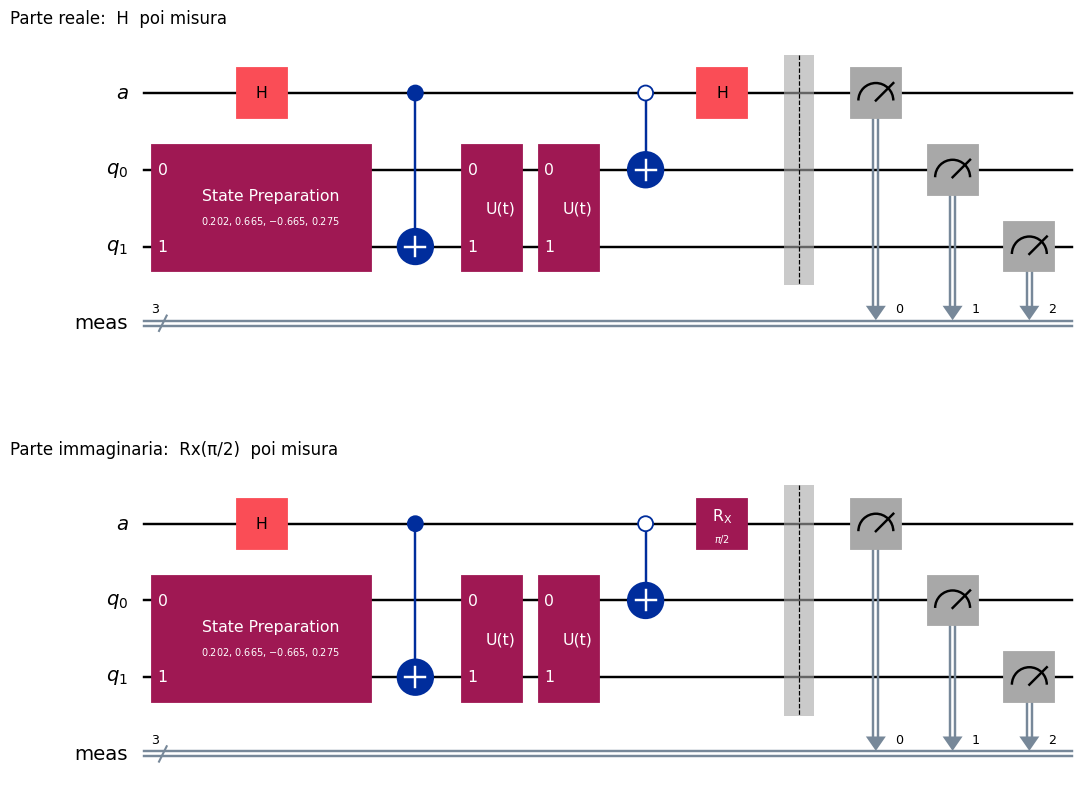

In [15]:
def costruisci_circuito_completo(i, alpha_V, j, beta_W, t, N, ramo):
    qc = costruisci_circuito(i, alpha_V, j, beta_W, t, N)
    if ramo == "Re":
        qc.h(0)
    elif ramo == "Im":
        qc.rx(np.pi / 2, 0)
    else:
        raise ValueError(ramo)
    qc.measure_all()
    return qc

qc_re = costruisci_circuito_completo(2, "x", 1, "x", t=2.0, N=2, ramo="Re")
qc_im = costruisci_circuito_completo(2, "x", 1, "x", t=2.0, N=2, ramo="Im")

fig, axes = plt.subplots(2, 1, figsize=(11, 9))
qc_re.draw("mpl", style="iqp", ax=axes[0], fold=-1)
axes[0].set_title("Parte reale:  H  poi misura", fontsize=12, loc="left")
qc_im.draw("mpl", style="iqp", ax=axes[1], fold=-1)
axes[1].set_title("Parte immaginaria:  Rx(π/2)  poi misura", fontsize=12, loc="left")
plt.tight_layout()
plt.show()

**Discussione.** Fedeltà 1 sulla preparazione del registro; accordo circuito/classico con
scarto che cresce con $t$ in modo coerente con l'errore di Trotter atteso ($t^2/N$).

**Nota di sincronizzazione**: questa funzione era rimasta, fino a questo aggiornamento, nella
versione non generalizzata (hardcoded su $i=2,j=1$) con una mappatura sito$\to$qubit invertita
— bug analogo a quello documentato e corretto in `correlazioni_dimero_esplorazione.ipynb`,
Sez. 11.1. Corretto qui per sincronia.

## 14. Riepilogo

- Il punto di partenza (Sez. 1) è un pattern osservato: $C_{11}^{\alpha\beta}=\pm
  C_{22}^{\alpha\beta}$ per ogni $t$, segno fisso dipendente solo da $(\alpha,\beta)$.
- Ripartendo da un fatto verificabile — $H_{\mathrm{ex}}+H_Z$ è invariante sotto
  $R_z(\theta)\otimes R_z(\theta)$ per ogni $\theta$ — e cercando un $\theta$ per cui
  $H_{\mathrm{DM}}$ resti "controllabile", il calcolo esplicito forza $\theta=\pi$, con
  $H_{\mathrm{DM}}\to-H_{\mathrm{DM}}$.
- Lo scambio dei due siti produce lo stesso segno: componendo le due operazioni si ottiene
  $U=\mathrm{SWAP}\cdot(R_z(\pi)\otimes R_z(\pi))$, simmetria esatta di $H$ per ogni $J,b,D$
  testato, che predice esattamente il pattern di Sez. 1.
- **Scan completo (Sez. 9):** nessuna delle 36 combinazioni è strutturalmente nulla — coerente
  con $U$, che lega sempre coppie diverse (mai zeri assoluti).
- **Zeri a $t=0$ (Sez. 10):** un argomento *diverso* da $U$ (realtà di $H$, time-reversal) dà
  zero rigoroso per le combinazioni a siti diversi con una sola componente $y$.
- **Selezione del correlatore (Sez. 11):** $C_{2,1}^{xx}$
  per rilevanza fisica, $C_{2,1}^{xy}$ per qualità del segnale.
- **Circuito con l'ancilla (Sez. 12-13):** blocco $U(t)$ Trotter in Pauli dirette, verificato
  contro `expm`; circuito completo validato su statevector contro $C(t)$ classico, accordo
  entro l'errore di Trotter atteso.

**Prossimo passo:** compilazione verso gate nativi e/o esecuzione con shot finiti/rumore.